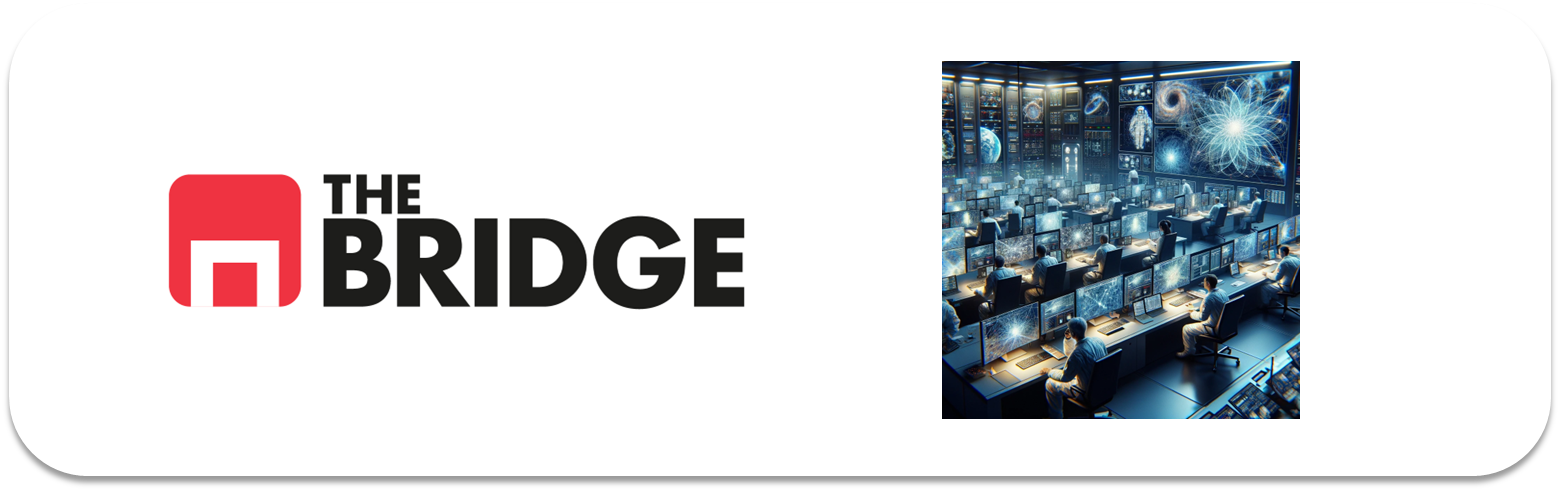

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



In [9]:
train_dirs = [
    Path("data/github_train_0"),
    Path("data/github_train_1"),
    Path("data/github_train_2"),
    Path("data/github_train_3")
]

test_dir = Path("data/github_test")

In [10]:
def get_label_from_filename(filename):
    """
    Extrae la clase a partir del nombre del archivo.
    Devuelve:
        0 -> cat
        1 -> dog
    """
    name = filename.lower()
    
    if "cat" in name:
        return 0
    elif "dog" in name:
        return 1
    else:
        raise ValueError(f"No se pudo inferir la clase desde el nombre: {filename}")

In [11]:
def load_and_resize_image(image_path, target_size=(32, 32)):
    """
    Lee una imagen, la convierte a RGB y la redimensiona.
    Devuelve un array numpy de forma (alto, ancho, 3).
    """
    img = Image.open(image_path).convert("RGB")
    img = img.resize(target_size)
    img_array = np.array(img)
    return img_array

In [12]:
def load_images_from_directory(directory, target_size=(32, 32)):
    """
    Lee todas las imágenes de un directorio.
    Devuelve:
        X -> array de imágenes
        y -> array de etiquetas
        filenames -> lista con nombres de archivo
    """
    images = []
    labels = []
    filenames = []
    
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    
    for file_path in sorted(directory.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            try:
                img_array = load_and_resize_image(file_path, target_size=target_size)
                label = get_label_from_filename(file_path.name)
                
                images.append(img_array)
                labels.append(label)
                filenames.append(file_path.name)
            except Exception as e:
                print(f"No se pudo procesar {file_path.name}: {e}")
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y, filenames

In [13]:
def load_images_from_directory(directory, target_size=(32, 32)):
    """
    Lee todas las imágenes de un directorio.
    Devuelve:
        X -> array de imágenes
        y -> array de etiquetas
        filenames -> lista con nombres de archivo
    """
    images = []
    labels = []
    filenames = []
    
    valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    
    for file_path in sorted(directory.iterdir()):
        if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
            try:
                img_array = load_and_resize_image(file_path, target_size=target_size)
                label = get_label_from_filename(file_path.name)
                
                images.append(img_array)
                labels.append(label)
                filenames.append(file_path.name)
            except Exception as e:
                print(f"No se pudo procesar {file_path.name}: {e}")
    
    X = np.array(images)
    y = np.array(labels)
    
    return X, y, filenames

In [14]:
X_train_parts = []
y_train_parts = []
train_filenames_parts = []

for directory in train_dirs:
    X_part, y_part, filenames_part = load_images_from_directory(directory, target_size=(32, 32))
    X_train_parts.append(X_part)
    y_train_parts.append(y_part)
    train_filenames_parts.extend(filenames_part)

X_train = np.concatenate(X_train_parts, axis=0)
y_train = np.concatenate(y_train_parts, axis=0)

In [15]:
X_test, y_test, test_filenames = load_images_from_directory(test_dir, target_size=(32, 32))

In [16]:
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (4000, 32, 32, 3)
Forma de y_train: (4000,)
Forma de X_test: (1000, 32, 32, 3)
Forma de y_test: (1000,)


In [17]:
class_names = {
    0: "cat",
    1: "dog"
}

In [18]:
print("Distribución de clases en train:")
print(pd.Series(y_train).map(class_names).value_counts())

print("\nDistribución de clases en test:")
print(pd.Series(y_test).map(class_names).value_counts())

Distribución de clases en train:
cat    2000
dog    2000
Name: count, dtype: int64

Distribución de clases en test:
cat    500
dog    500
Name: count, dtype: int64


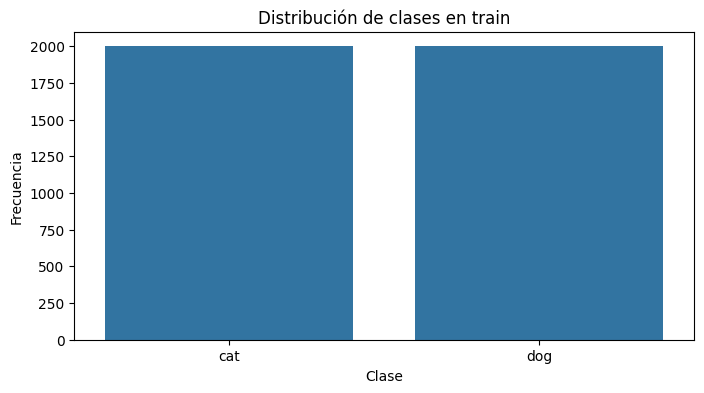

In [19]:
plt.figure(figsize=(8, 4))
sns.countplot(x=pd.Series(y_train).map(class_names))
plt.title("Distribución de clases en train")
plt.xlabel("Clase")
plt.ylabel("Frecuencia")
plt.show()

In [20]:
def plot_images(images, labels, class_names, n_cols=5, figsize=(15, 8)):
    n_images = len(images)
    n_rows = (n_images - 1) // n_cols + 1
    
    plt.figure(figsize=figsize)
    
    for i in range(n_images):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

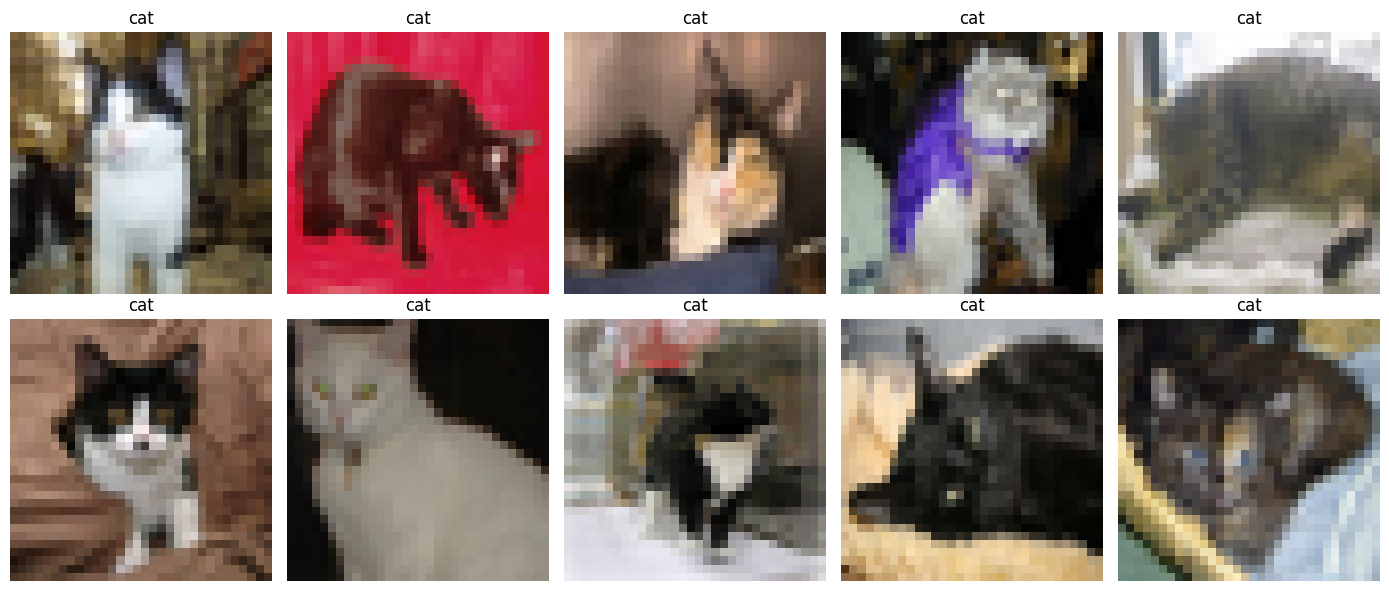

In [21]:
plot_images(X_train[:10], y_train[:10], class_names, n_cols=5, figsize=(14, 6))

In [22]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

In [23]:
print("Valor mínimo en X_train:", X_train.min())
print("Valor máximo en X_train:", X_train.max())

Valor mínimo en X_train: 0.0
Valor máximo en X_train: 1.0


In [29]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    
    layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid")
])

In [27]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,289 (532.38 KB)

 Trainable params: 136,289 (532.38 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [34]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

In [35]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.6269 - loss: 0.6584 - val_accuracy: 0.0088 - val_loss: 0.9795
Epoch 2/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6669 - loss: 0.6125 - val_accuracy: 0.4538 - val_loss: 0.7642
Epoch 3/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6772 - loss: 0.5897 - val_accuracy: 0.2650 - val_loss: 1.0036
Epoch 4/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7191 - loss: 0.5618 - val_accuracy: 0.4363 - val_loss: 0.8681
Epoch 5/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7312 - loss: 0.5430 - val_accuracy: 0.6612 - val_loss: 0.6654
Epoch 6/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7431 - loss: 0.5304 - val_accuracy: 0.5163 - val_loss: 0.8480
Epoch 7/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7522 - loss: 0.5036 - val_accuracy: 0.5725 - val_loss: 0.7534
Epoch 8/20
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7753 - loss: 0.4730 - val_accura

In [36]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

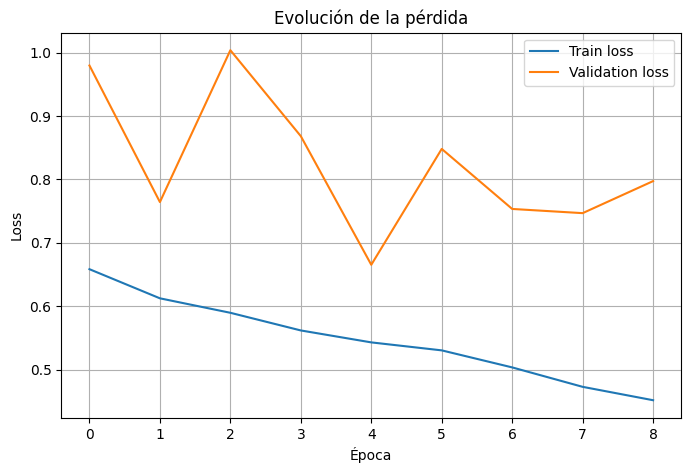

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

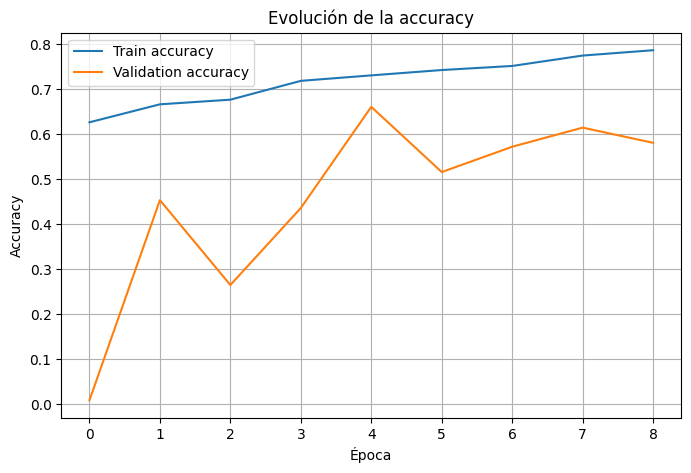

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Evolución de la accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [39]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.6000532507896423
Test accuracy: 0.6859999895095825


In [40]:
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [41]:
print("Primeras 10 probabilidades:")
print(y_pred_prob[:10])

print("\nPrimeras 10 clases predichas:")
print(y_pred[:10])

Primeras 10 probabilidades:
[0.5224824  0.39955565 0.2457972  0.46214187 0.66888094 0.16646385
 0.20137662 0.36145213 0.68463194 0.29995674]

Primeras 10 clases predichas:
[1 0 0 0 1 0 0 0 1 0]


In [42]:
print(classification_report(y_test, y_pred, target_names=["cat", "dog"]))

              precision    recall  f1-score   support

         cat       0.68      0.72      0.70       500
         dog       0.70      0.66      0.68       500

    accuracy                           0.69      1000
   macro avg       0.69      0.69      0.69      1000
weighted avg       0.69      0.69      0.69      1000



In [43]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[358, 142],
       [172, 328]])

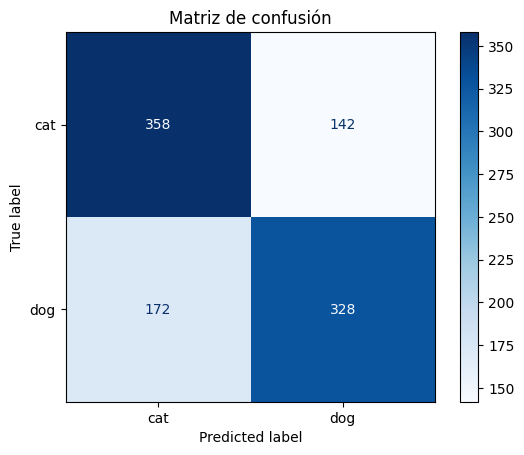

In [44]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"])
disp.plot(cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

In [45]:
def plot_prediction_examples(images, y_true, y_pred, y_prob, class_names, n=8):
    plt.figure(figsize=(16, 8))
    
    for i in range(n):
        plt.subplot(2, 4, i + 1)
        plt.imshow(images[i])
        
        true_label = class_names[int(y_true[i])]
        pred_label = class_names[int(y_pred[i])]
        
        # confianza de la clase predicha
        confidence = y_prob[i] if y_pred[i] == 1 else 1 - y_prob[i]
        
        color = "blue" if y_true[i] == y_pred[i] else "red"
        
        plt.title(
            f"Real: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}",
            color=color
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

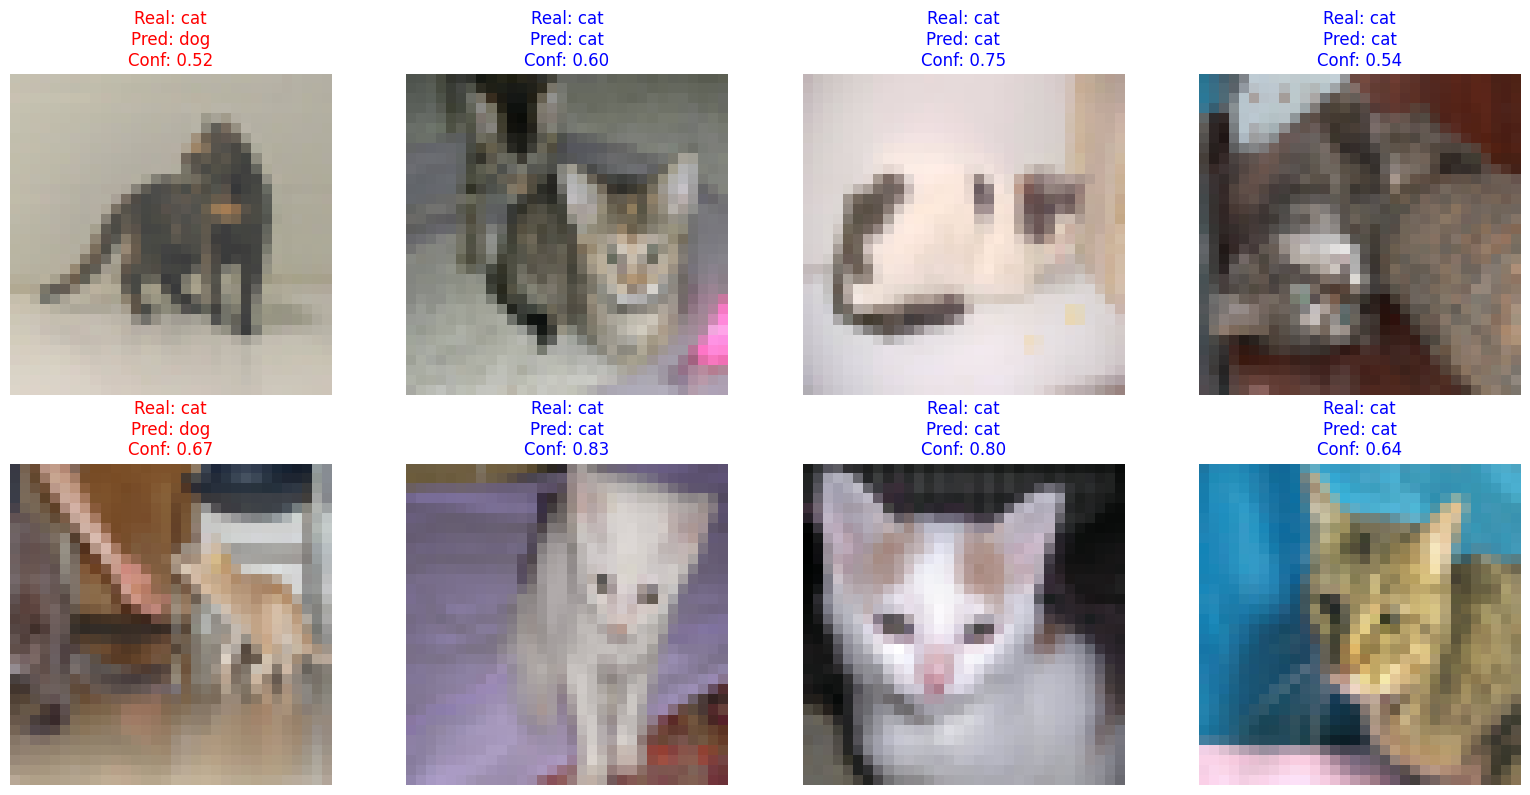

In [46]:
plot_prediction_examples(X_test, y_test, y_pred, y_pred_prob, class_names, n=8)

In [47]:
misclassified_idx = np.where(y_test != y_pred)[0]
len(misclassified_idx)

314

In [48]:
print("Número de imágenes mal clasificadas:", len(misclassified_idx))
print("Porcentaje de errores en test:", len(misclassified_idx) / len(y_test))

Número de imágenes mal clasificadas: 314
Porcentaje de errores en test: 0.314


In [49]:
# gatos reales (0) clasificados como perros (1)
cat_as_dog_idx = np.where((y_test == 0) & (y_pred == 1))[0]

# perros reales (1) clasificados como gatos (0)
dog_as_cat_idx = np.where((y_test == 1) & (y_pred == 0))[0]

print("Gatos clasificados como perros:", len(cat_as_dog_idx))
print("Perros clasificados como gatos:", len(dog_as_cat_idx))

Gatos clasificados como perros: 142
Perros clasificados como gatos: 172


In [50]:
# confianza errónea para gatos clasificados como perros
cat_as_dog_conf = y_pred_prob[cat_as_dog_idx]

# confianza errónea para perros clasificados como gatos
dog_as_cat_conf = 1 - y_pred_prob[dog_as_cat_idx]

In [51]:
def select_top_10_percent(indices, confidences):
    if len(indices) == 0:
        return np.array([], dtype=int), np.array([], dtype=float)
    
    n_select = max(1, int(np.ceil(len(indices) * 0.10)))
    order = np.argsort(confidences)[::-1]
    
    selected_indices = indices[order[:n_select]]
    selected_confidences = confidences[order[:n_select]]
    
    return selected_indices, selected_confidences

In [52]:
top_cat_as_dog_idx, top_cat_as_dog_conf = select_top_10_percent(cat_as_dog_idx, cat_as_dog_conf)
top_dog_as_cat_idx, top_dog_as_cat_conf = select_top_10_percent(dog_as_cat_idx, dog_as_cat_conf)

print("Top 10% gatos->perros:", len(top_cat_as_dog_idx))
print("Top 10% perros->gatos:", len(top_dog_as_cat_idx))

Top 10% gatos->perros: 15
Top 10% perros->gatos: 18


In [53]:
selected_rows = []

for idx, conf in zip(top_cat_as_dog_idx, top_cat_as_dog_conf):
    selected_rows.append({
        "index_test": idx,
        "filename": test_filenames[idx],
        "true_class": "cat",
        "pred_class": "dog",
        "wrong_class_confidence": conf
    })

for idx, conf in zip(top_dog_as_cat_idx, top_dog_as_cat_conf):
    selected_rows.append({
        "index_test": idx,
        "filename": test_filenames[idx],
        "true_class": "dog",
        "pred_class": "cat",
        "wrong_class_confidence": conf
    })

selected_df = pd.DataFrame(selected_rows)
selected_df = selected_df.sort_values("wrong_class_confidence", ascending=False).reset_index(drop=True)

selected_df

,index_test,filename,true_class,pred_class,wrong_class_confidence
0,680,dog.8764.jpg,dog,cat,0.997754
1,749,dog.8979.jpg,dog,cat,0.982940
2,666,dog.8707.jpg,dog,cat,0.962492
3,537,dog.8215.jpg,dog,cat,0.952587
4,344,cat.11825.jpg,cat,dog,0.920679
5,886,dog.9499.jpg,dog,cat,0.901202
6,851,dog.9346.jpg,dog,cat,0.900846
7,926,dog.9631.jpg,dog,cat,0.897568
8,738,dog.8951.jpg,dog,cat,0.891938
9,874,dog.9457.jpg,dog,cat,0.880522


In [54]:
def plot_selected_errors(images, y_true, y_pred, y_prob, indices, class_names, n=8):
    n = min(n, len(indices))
    
    if n == 0:
        print("No hay imágenes para mostrar.")
        return
    
    plt.figure(figsize=(16, 8))
    
    for j in range(n):
        i = indices[j]
        plt.subplot(2, 4, j + 1)
        plt.imshow(images[i])
        
        true_label = class_names[int(y_true[i])]
        pred_label = class_names[int(y_pred[i])]
        confidence = y_prob[i] if y_pred[i] == 1 else 1 - y_prob[i]
        
        plt.title(
            f"Real: {true_label}\nPred: {pred_label}\nConf errónea: {confidence:.2f}",
            color="red"
        )
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

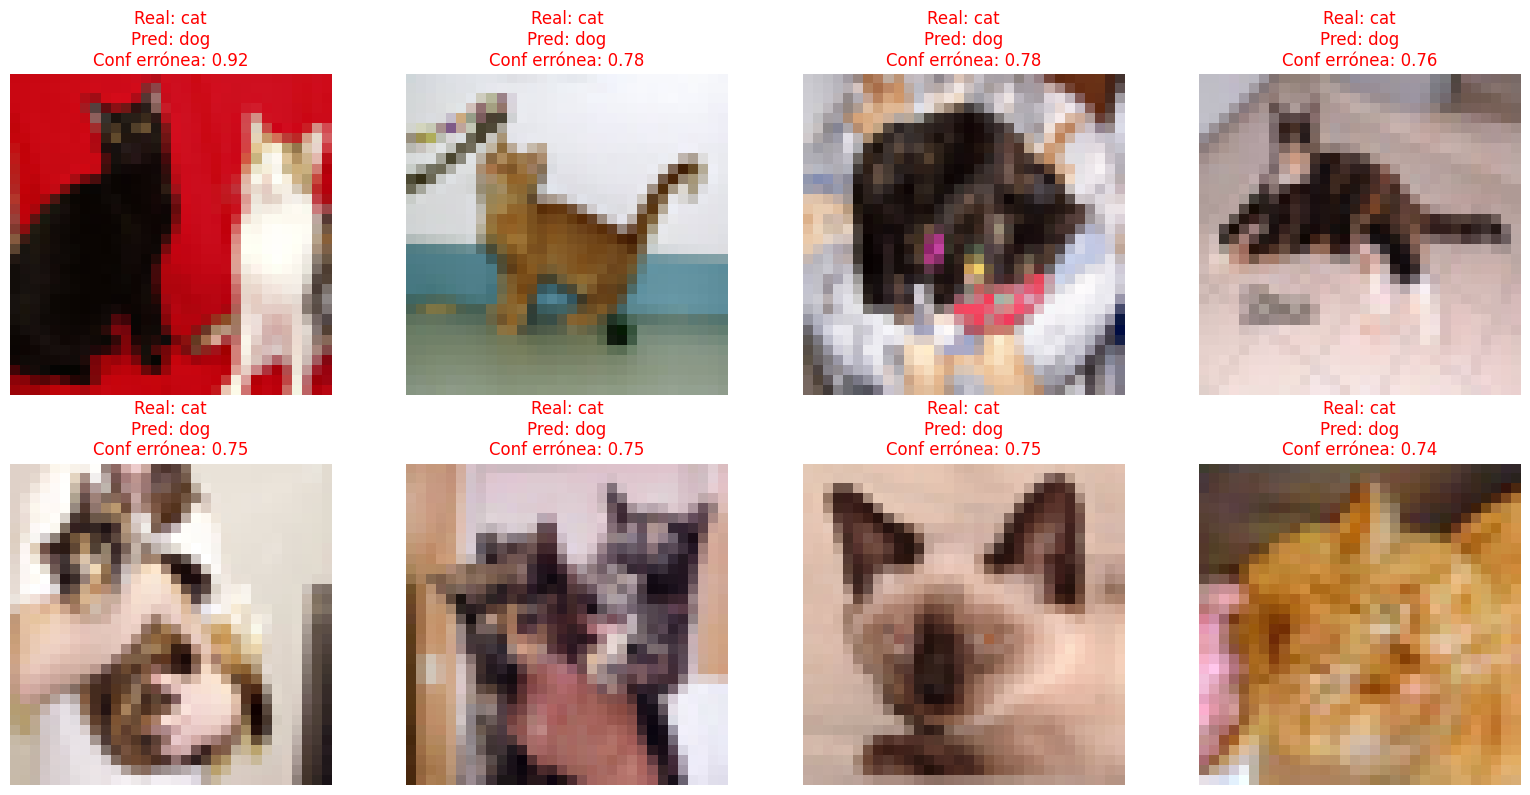

In [55]:
plot_selected_errors(X_test, y_test, y_pred, y_pred_prob, top_cat_as_dog_idx, class_names, n=8)

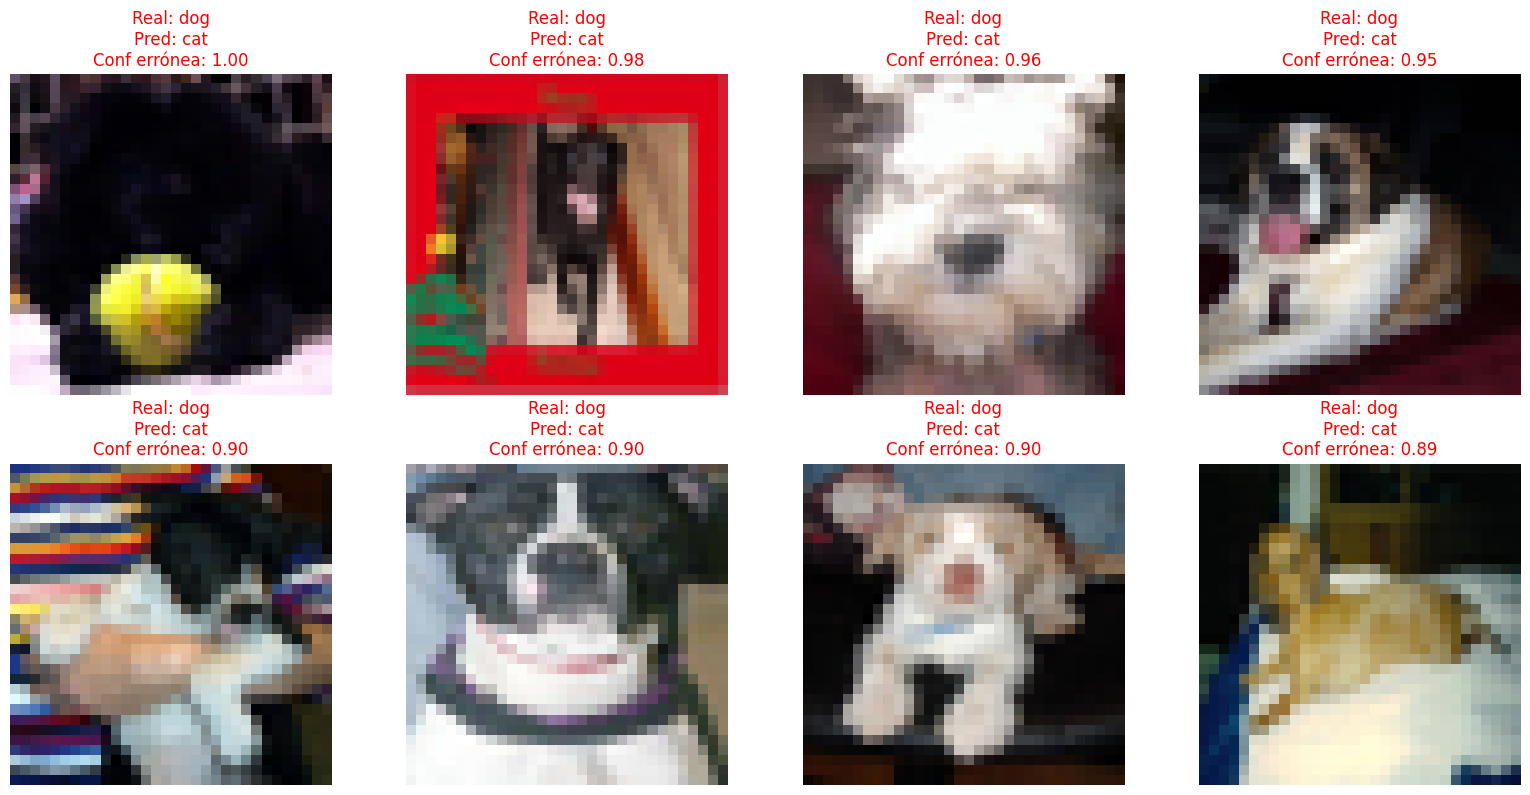

In [56]:
plot_selected_errors(X_test, y_test, y_pred, y_pred_prob, top_dog_as_cat_idx, class_names, n=8)